# 07 · Mock SBI with SNLE

NLE trained on the pasted responses, evaluated on the noiseless pasted mock observation.
NLE and not NPE: it learns `p(x | theta)` and applies the box prior analytically at MCMC
time, so the design never enters the estimated object and there is no proposal correction
to get wrong.

`oracle_mock_selfconsistent_test.py` (builds the score operator) · `run_mock_sbi_snle.py` ·
`plot_three_way_triangle.py`

In [1]:
import json, pathlib, sys
import numpy as np, h5py
import matplotlib.pyplot as plt
ROOT = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX")
sys.path.insert(0, str(ROOT / "notebooks/SBI_validate/common"))
DATA = ROOT / "data/SBI_validate"
VAL  = DATA / "three_probe_mock/validation"
INF  = DATA / "three_probe_inference"
MSBI = DATA / "mock_sbi"
BLUE, ORANGE, GREEN, INK2, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#dedcd6"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GRID, "xtick.color": INK2, "ytick.color": INK2,
                     "font.size": 10.5, "axes.spines.top": False, "axes.spines.right": False})
SPECTRA = ["gy", "gkappa", "gtau"]
LBL = {"gg": r"$g \times g$", "gy": r"$g \times y$",
       "gkappa": r"$g \times \kappa_{\rm CMB}$", "gtau": r"$g \times \tau$"}

In [2]:
PARAMS = ["theta_ej_0", "alpha_nt", "mu_beta", "theta_co_0", "nu_theta_ej_M"]
post = np.load(MSBI / "trial/mock_snle_n0038_posterior.npz", allow_pickle=True)
mock, u_mock = np.asarray(post["theta"]), np.asarray(post["u"])
man = json.loads(str(post["manifest_json"]))
print(f"{man['estimator']}  ->  {mock.shape[0]:,} samples")
print(f"  {man['n_pasted_points']} pasted points x "
      f"{man['n_training_rows']//man['n_pasted_points']} noise draws = "
      f"{man['n_training_rows']:,} rows")
print(f"  {man['seeds']} pooled network seeds; largest single-seed departure "
      f"{man['max_seed_departure_sigma']:.3f} sigma")
print(f"  proposal correction required: {man['proposal_correction_required']}")
print(f"  observation: {man['observation_kind']}")

SNLE (NLE, one round)  ->  80,000 samples
  94 pasted points x 64 noise draws = 6,016 rows
  4 pooled network seeds; largest single-seed departure 0.397 sigma
  proposal correction required: False
  observation: pasted_map_measurement_noiseless


### Seed-to-seed spread\n\nA single NLE seed is not quotable; the ensemble spread is the reason the run pools four.

orange line = the pooled mean


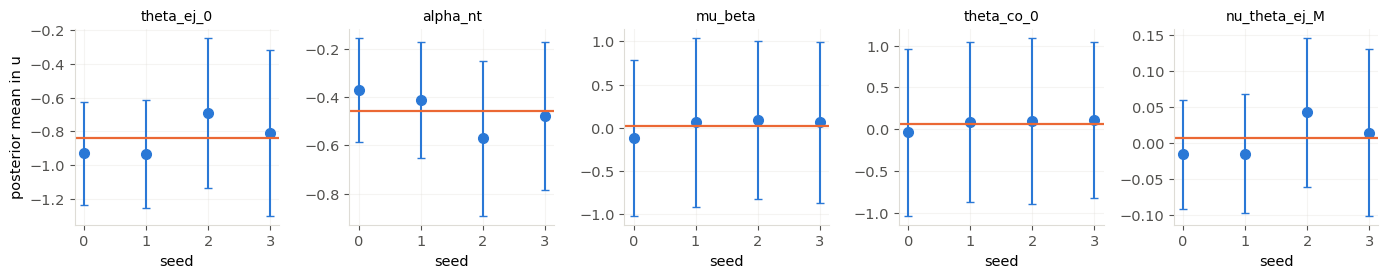

In [3]:
seeds = [np.asarray(post[f"u_seed_{i}"]) for i in range(man["seeds"])]
fig, axes = plt.subplots(1, 5, figsize=(14, 2.9))
for j, (ax, p) in enumerate(zip(axes, PARAMS)):
    for i, s in enumerate(seeds):
        ax.plot(i, s[:, j].mean(), "o", ms=7, color=BLUE)
        ax.errorbar(i, s[:, j].mean(), yerr=s[:, j].std(ddof=1), color=BLUE, capsize=3)
    ax.axhline(u_mock[:, j].mean(), color=ORANGE, lw=1.6)
    ax.set_title(p, fontsize=10); ax.set_xlabel("seed"); ax.set_xticks(range(len(seeds)))
    ax.grid(alpha=.3, color=GRID)
axes[0].set_ylabel("posterior mean in u")
fig.tight_layout()
print("orange line = the pooled mean")

### All three posteriors

In [4]:
# Constants are defined here rather than imported from plot_three_way_triangle.py:
# that module calls matplotlib.use("Agg") at import, which switches the backend away
# from the notebook's inline one and silently stops every later figure displaying.
TRUTH = np.array([2.0, 0.18, 0.6, 0.05, 0.0])
LABELS = [r"$\theta_{\rm ej,0}$", r"$\alpha_{\rm nt}$", r"$\mu_\beta$",
          r"$\theta_{\rm co,0}$", r"$\nu_{\theta_{\rm ej},M}$"]

In [5]:
raw = np.load(INF / "hmc_sc/run01/hmc_samples.npz")
hmc = np.stack([np.asarray(raw[f"sample_{p}"]).reshape(-1) for p in PARAMS], 1)
u_hmc = np.asarray(raw["u"]).reshape(-1, 5)
sbi = np.load(INF / "sbi_sc/run01/posterior_samples_round_4.npz")
npe, u_npe = np.asarray(sbi["theta"]), np.asarray(sbi["u"])

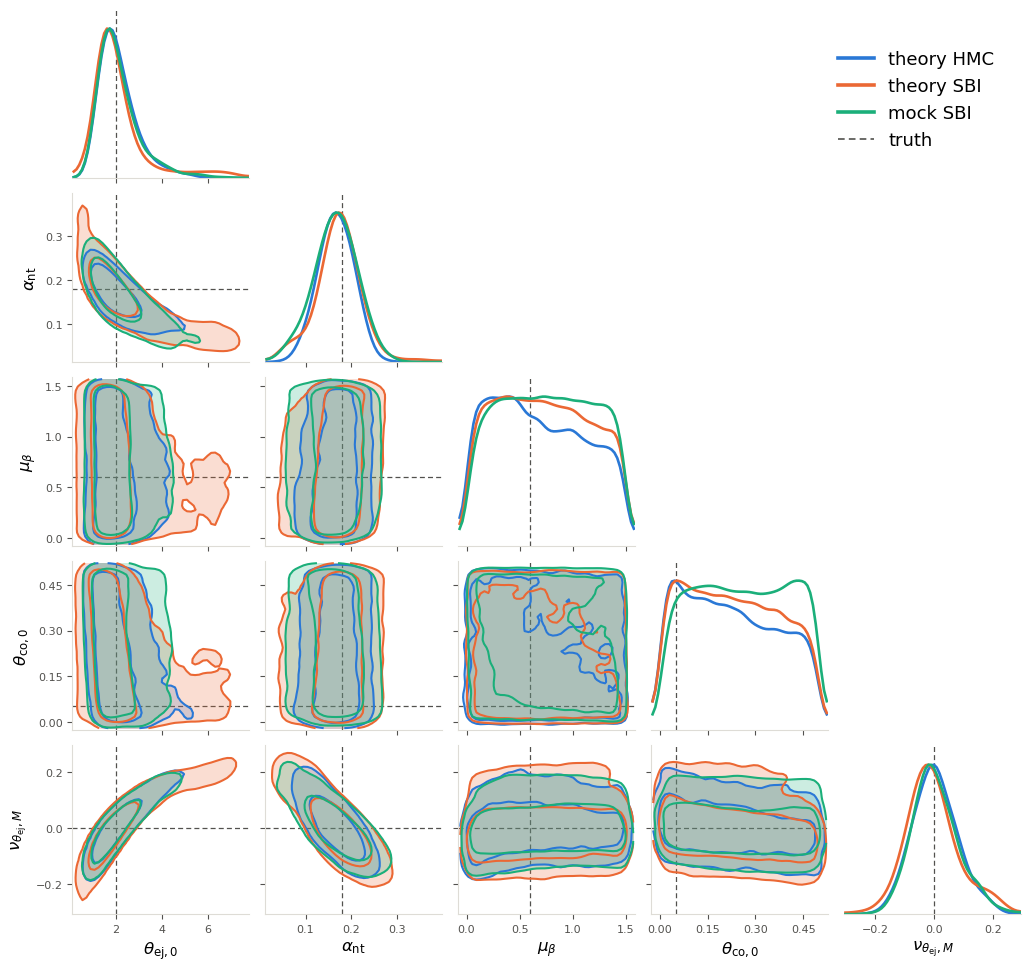

In [6]:
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D
def triangle(chains, colors, names, points=None):
    n, B1, S1, B2, S2 = 5, 64, 2.4, 44, 1.35
    lo, hi = np.empty(n), np.empty(n)
    for j in range(n):
        q = np.concatenate([np.percentile(c[:, j], [0.3, 99.7]) for c in chains])
        if points is not None: q = np.r_[q, points[:, j].min(), points[:, j].max()]
        pad = .06 * (q.max() - q.min()); lo[j], hi[j] = q.min() - pad, q.max() + pad
    fig, ax = plt.subplots(n, n, figsize=(10.6, 10.0))
    for i in range(n):
        for j in range(n):
            a = ax[i, j]
            if j > i: a.axis("off"); continue
            if i == j:
                for c, col in zip(chains, colors):
                    h, e = np.histogram(c[:, j], bins=B1, range=(lo[j], hi[j]), density=True)
                    h = gaussian_filter(h, S1); a.plot(.5*(e[:-1]+e[1:]), h/h.max(), color=col, lw=1.9)
                a.set_ylim(0, 1.13); a.set_yticks([]); a.spines["left"].set_visible(False)
            else:
                for kk, (c, col) in enumerate(zip(chains, colors)):
                    H, xe, ye = np.histogram2d(c[:, j], c[:, i], bins=B2,
                                               range=[[lo[j], hi[j]], [lo[i], hi[i]]])
                    H = gaussian_filter(H.T, S2)
                    if H.max() <= 0: continue
                    f = np.sort(H.ravel())[::-1]; cs = np.cumsum(f); cs /= cs[-1]
                    lv = sorted({float(f[min(int(np.searchsorted(cs, q)), f.size-1)])
                                 for q in (.68, .95)})
                    xc, yc = .5*(xe[:-1]+xe[1:]), .5*(ye[:-1]+ye[1:])
                    a.contourf(xc, yc, H, levels=lv+[H.max()*1.001], colors=col, alpha=.22, zorder=1+kk)
                    a.contour(xc, yc, H, levels=lv, colors=col, linewidths=1.5, zorder=5+kk)
                if points is not None:
                    a.plot(points[:, j], points[:, i], "o", ms=3.2, mfc="none", mec="k",
                           mew=.75, alpha=.85, zorder=20)
                a.set_ylim(lo[i], hi[i])
            a.axvline(TRUTH[j], color=INK2, lw=.9, ls=(0,(4,2.5)), zorder=0)
            if i != j: a.axhline(TRUTH[i], color=INK2, lw=.9, ls=(0,(4,2.5)), zorder=0)
            a.set_xlim(lo[j], hi[j]); a.tick_params(labelsize=8)
            a.xaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))
            if i != j: a.yaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))
            if i == n-1: a.set_xlabel(LABELS[j], fontsize=12)
            else: a.set_xticklabels([])
            if j == 0 and i > 0: a.set_ylabel(LABELS[i], fontsize=12)
            elif j != 0: a.set_yticklabels([])
    hs = [Line2D([], [], color=c, lw=2.6, label=nm) for c, nm in zip(colors, names)]
    if points is not None:
        hs.append(Line2D([], [], color="k", marker="o", ms=5, mfc="none", ls="none",
                         label="design points"))
    hs.append(Line2D([], [], color=INK2, lw=1.2, ls=(0,(4,2.5)), label="truth"))
    fig.legend(handles=hs, loc="upper right", bbox_to_anchor=(.975, .96), frameon=False,
               fontsize=13)
    fig.subplots_adjust(left=.09, right=.985, top=.985, bottom=.08, wspace=.09, hspace=.09)
    return fig
_ = triangle([hmc, npe, mock], [BLUE, ORANGE, GREEN],
             ["theory HMC", "theory SBI", "mock SBI"])

### Mean drift and 90% width ratio against theory HMC

In [7]:
w90 = lambda x: np.percentile(x, 95, 0) - np.percentile(x, 5, 0)
print(f"{'parameter':<16}{'SBI drift':>11}{'SBI w90':>9}{'mock drift':>12}{'mock w90':>10}")
for j, p in enumerate(PARAMS):
    print(f"{p:<16}"
          f"{(u_npe[:,j].mean()-u_hmc[:,j].mean())/u_hmc[:,j].std(ddof=1):>+11.3f}"
          f"{w90(u_npe)[j]/w90(u_hmc)[j]:>9.3f}"
          f"{(u_mock[:,j].mean()-u_hmc[:,j].mean())/u_hmc[:,j].std(ddof=1):>+12.3f}"
          f"{w90(u_mock)[j]/w90(u_hmc)[j]:>10.3f}")

parameter         SBI drift  SBI w90  mock drift  mock w90
theta_ej_0           -0.075    1.547      +0.014     1.086
alpha_nt             +0.089    1.415      -0.074     1.340
mu_beta              +0.105    0.977      +0.175     0.945
theta_co_0           +0.042    0.982      +0.233     0.964
nu_theta_ej_M        -0.130    1.223      +0.021     1.025


**Status.** This is the 94-point trial, not the full 128-point round. Against the relaxed
gate (0.20 sigma drift, 20% width) `theta_co_0` drift and `alpha_nt` width both fail;
`mu_beta` and `theta_co_0` are unconstrained by these three spectra (posterior sd ~= prior
sd), so their drifts are wobbles in a near-flat marginal. On widths, mock SBI is closer to
theory HMC than theory SBI is in four of five parameters.